# Audio Signal Type Recognition

### Loading Required Packages

In [1]:
import glob
import warnings
import wave
from os import path

import matplotlib.pyplot as plt
import pandas as pd
import pylab
from scipy.fftpack import fft
from scipy.io import wavfile as wav
from sklearn import ensemble, linear_model, metrics, svm
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')


### Audio File Exploration Tools

In [2]:
def plot_spectrogram(audio_path: str):
    """
    Renders a spectrogram for the specified WAV file.
    """
    signal_values, sample_rate = read_wav_metadata(audio_path)
    pylab.figure(figsize=(15, 5))
    pylab.subplot(111)
    pylab.axis('off')
    pylab.title(f"Spectrogram: {audio_path}")
    pylab.xlabel('frequency')
    pylab.ylabel('time')
    pylab.specgram(signal_values, Fs=sample_rate)


def plot_wave(audio_path: str):
    """
    Displays the audio signal amplitude waveform over time.
    """
    signal_values, _ = read_wav_metadata(audio_path)
    plt.figure(num=1, figsize=(15, 5))
    plt.title(f"Signal waveform: {audio_path}")
    plt.xlabel('time')
    plt.ylabel('amplitude')
    plt.plot(signal_values)
    plt.show()


def plot_fft(audio_path: str):
    """
    Displays the Fast Fourier Transform magnitude for the audio file.
    """
    fft_values = build_fft_vector(audio_path)
    fft_size = len(fft_values)
    plt.figure(figsize=(15, 5))
    plt.ylim(0, 50000)
    plt.title(f"FFT: {audio_path}")
    plt.xlabel('frequency')
    plt.ylabel('amplitude')
    plt.plot(abs(fft_values[: int(fft_size) - 1]), 'r')
    plt.show()


def build_fft_vector(audio_path: str) -> list:
    """
    Returns a feature vector built from FFT.
    """
    _, raw_audio = wav.read(audio_path)
    left_channel = raw_audio.T[0]
    normalized_signal = [(sample / 2**8.0) * 2 - 1 for sample in left_channel]
    fft_result = fft(normalized_signal)
    half_length = len(fft_result) / 2
    return abs(fft_result[: int(half_length) - 1])


def read_wav_metadata(audio_path: str) -> tuple:
    """
    Reads audio samples and the sampling rate.
    """
    wav_handle = wave.open(audio_path, 'r')
    frame_buffer = wav_handle.readframes(-1)
    signal_values = pylab.fromstring(frame_buffer, 'int16')
    sample_rate = wav_handle.getframerate()
    wav_handle.close()
    return signal_values, sample_rate


### Example: Ambulance Siren

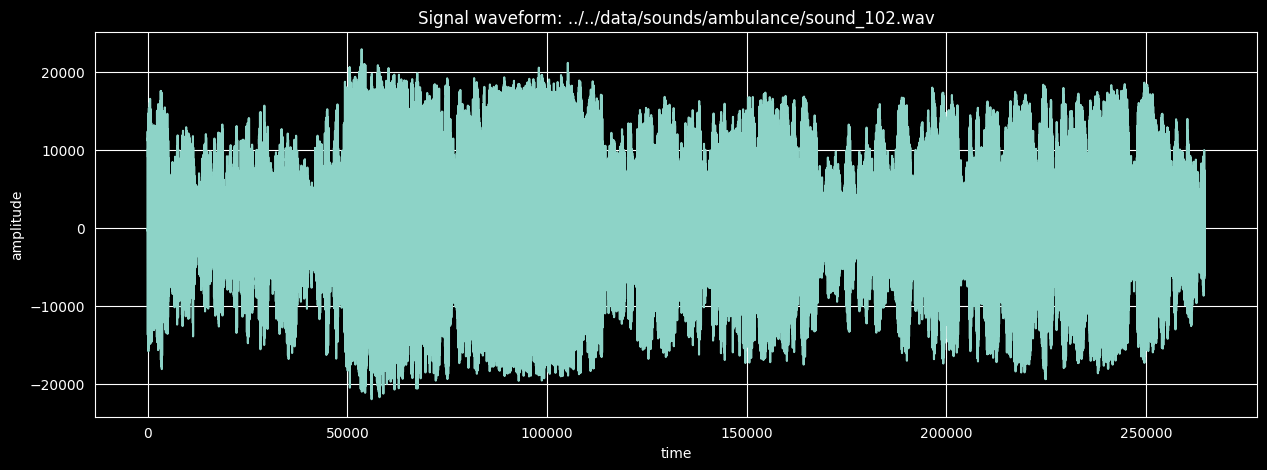

In [3]:
plot_wave('../../data/sounds/ambulance/sound_102.wav')


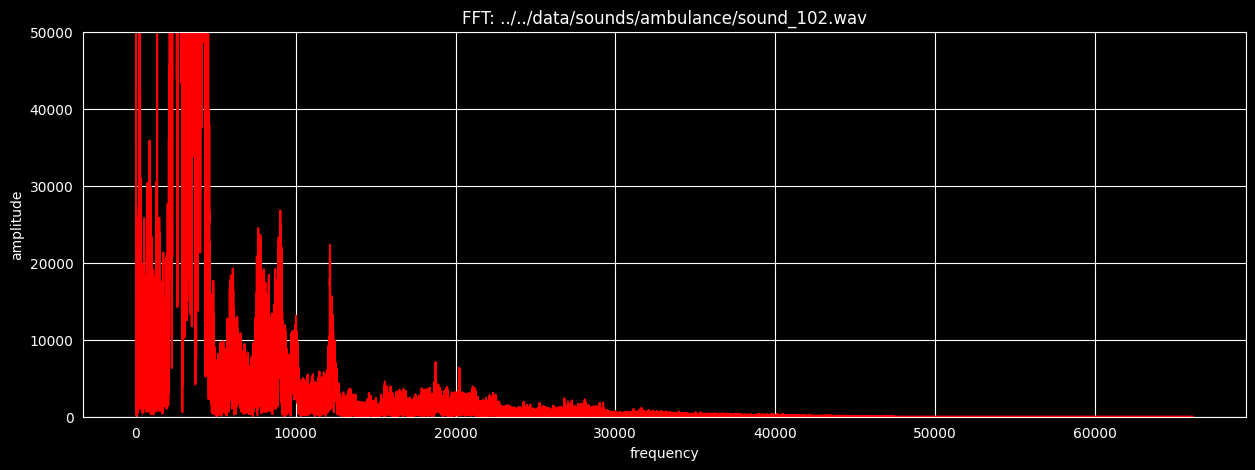

In [4]:
plot_fft('../../data/sounds/ambulance/sound_102.wav')


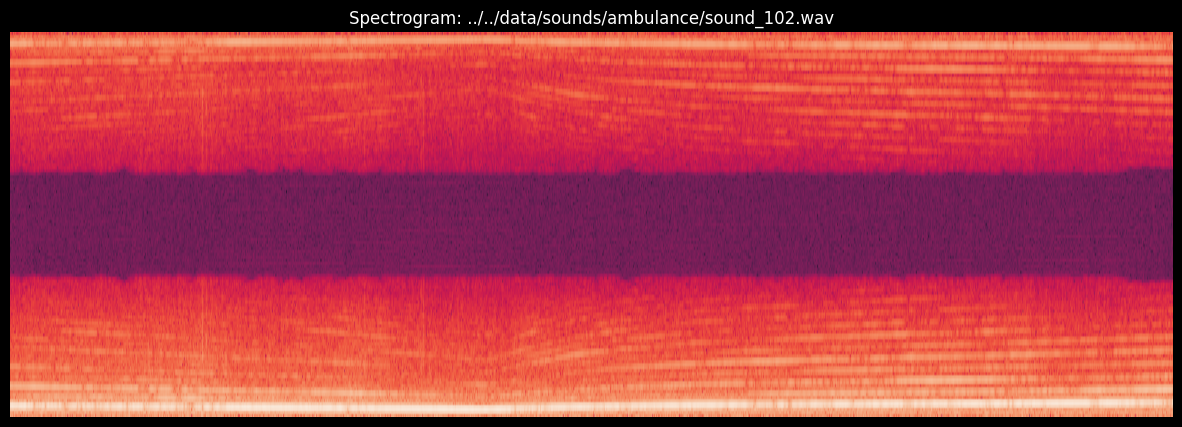

In [5]:
plot_spectrogram('../../data/sounds/ambulance/sound_102.wav')


### Example: Fire Truck Signal

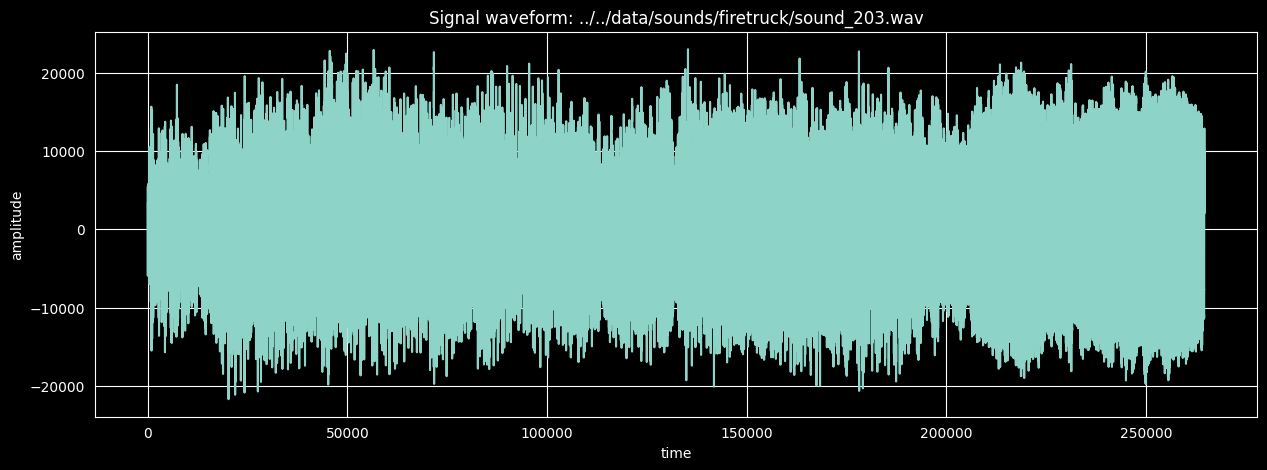

In [6]:
plot_wave('../../data/sounds/firetruck/sound_203.wav')


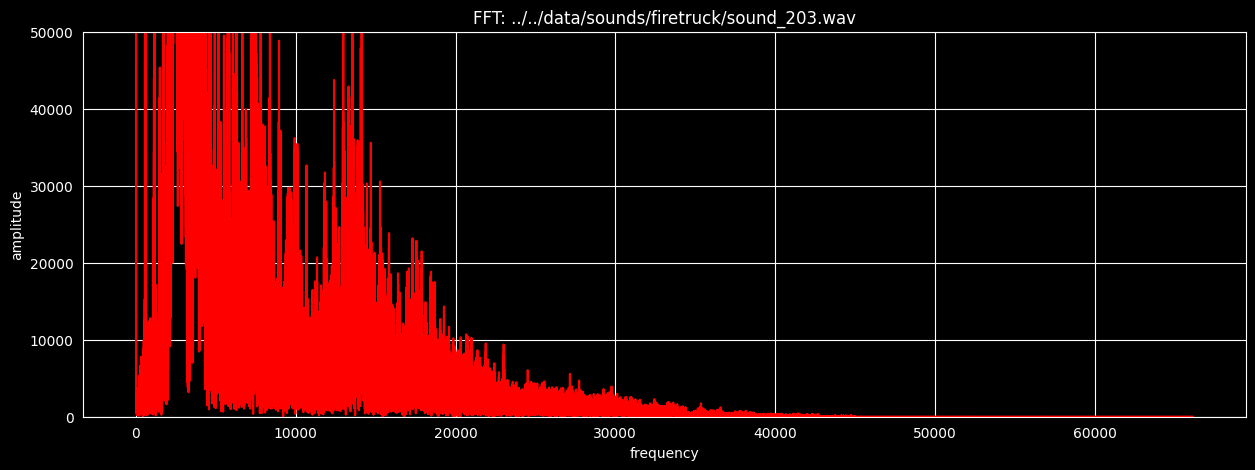

In [7]:
plot_fft('../../data/sounds/firetruck/sound_203.wav')


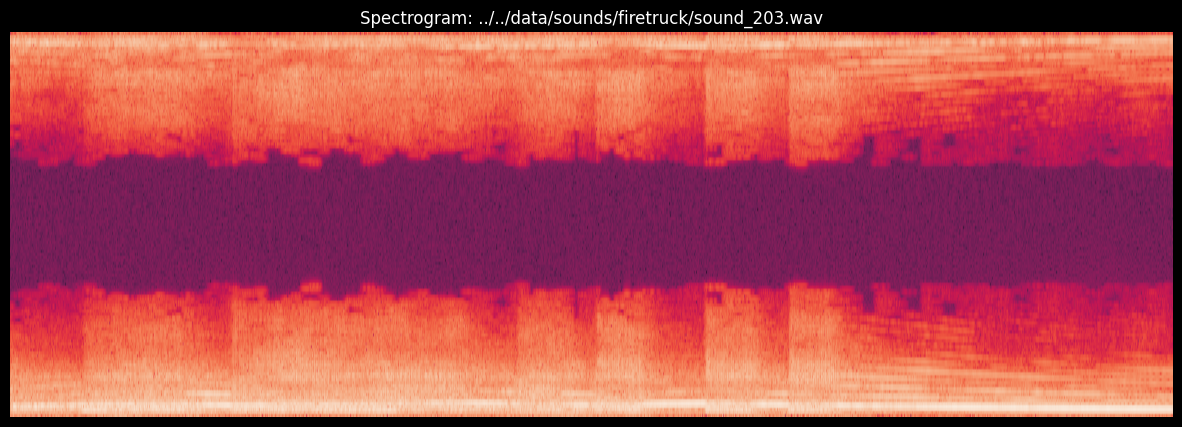

In [8]:
plot_spectrogram('../../data/sounds/firetruck/sound_203.wav')


### Example: Traffic Noise

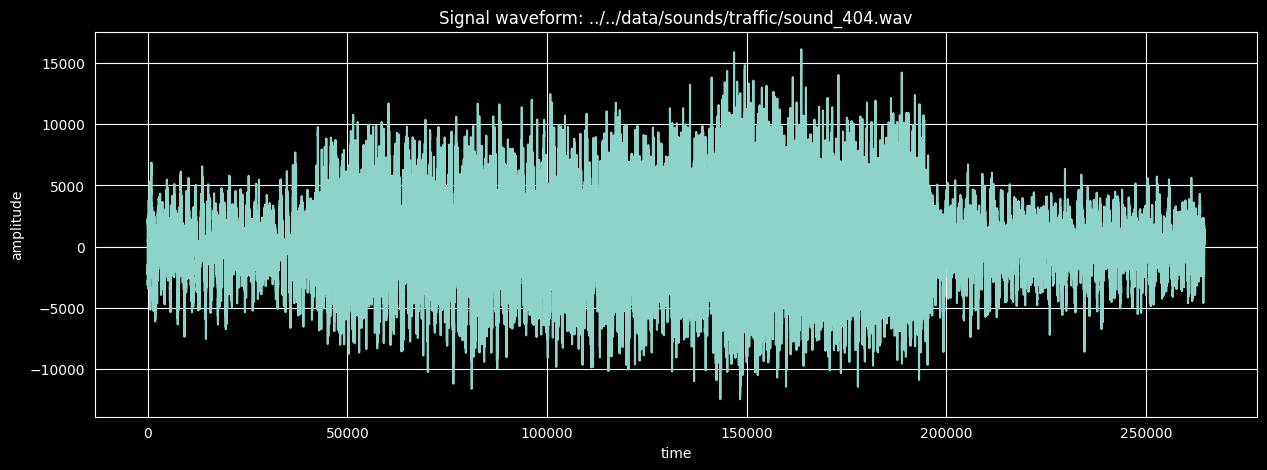

In [9]:
plot_wave('../../data/sounds/traffic/sound_404.wav')


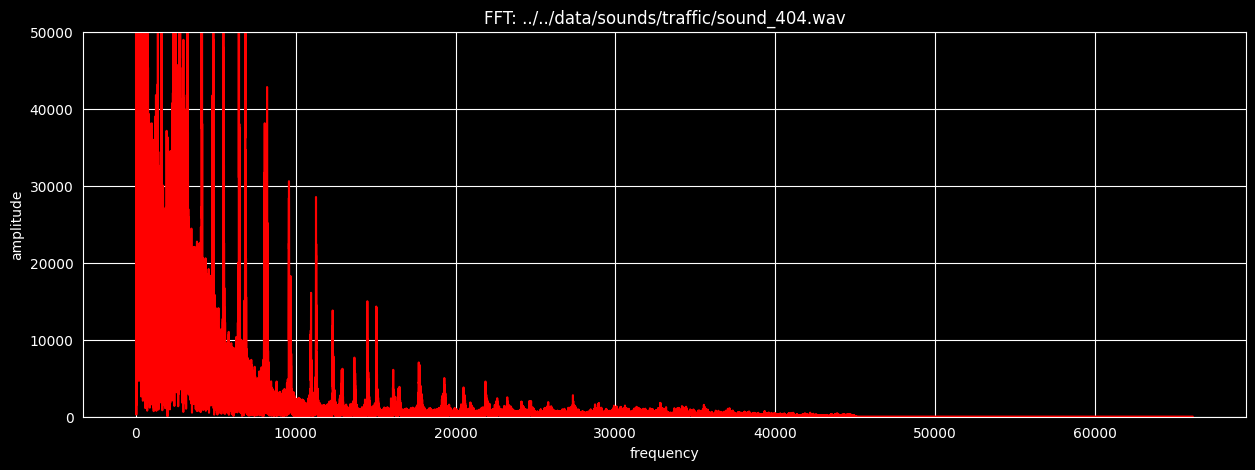

In [10]:
plot_fft('../../data/sounds/traffic/sound_404.wav')


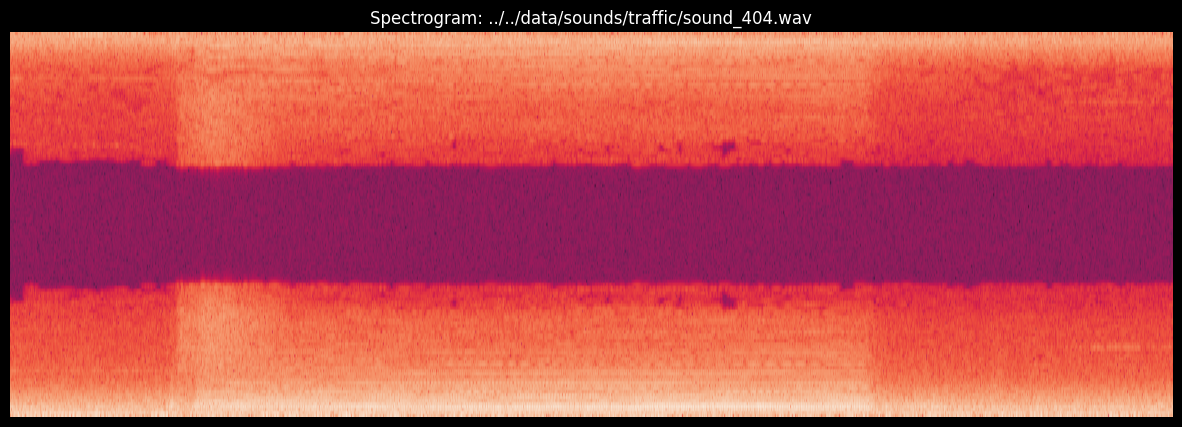

In [11]:
plot_spectrogram('../../data/sounds/traffic/sound_404.wav')


### Building the FFT Feature Matrix and Class Labels

In [ ]:
feature_rows = []
class_labels = []

class_map = {
    'ambulance': 1,
    'firetruck': 2,
    'traffic': 3,
}


def collect_example(file_path):
    try:
        path_parts = file_path.split('/')
        feature_rows.append(build_fft_vector(file_path)[:50000:3])
        class_labels.append(class_map[path_parts[3]])
    except:
        pass


audio_files = glob.glob(path.join('', '../../data/sounds/**/**'))
dataset_build = [collect_example(single_file) for single_file in tqdm(audio_files)]


  0%|          | 0/600 [00:00<?, ?it/s]

### Data Split and Training/Evaluation Procedure

In [ ]:
train_features, test_features, train_labels, test_labels = train_test_split(
    feature_rows,
    class_labels,
    test_size=0.2,
    random_state=12345,
)


def fit_and_score(model, train_vectors, target_values, valid_vectors):
    # fit model to training data
    model.fit(train_vectors, target_values)

    # predictions on validation set
    predicted_labels = model.predict(valid_vectors)

    # compute basic quality metrics
    metric_values = list(metrics.precision_recall_fscore_support(predicted_labels, test_labels))
    summary_scores = [
        metric_values[0][0],
        metric_values[1][0],
        metric_values[2][0],
    ]
    summary_scores.append(metrics.accuracy_score(predicted_labels, test_labels))
    return model, summary_scores


### Testing Several Classification Approaches

In [ ]:
# Variant 1 - logistic regression
_, model_scores = fit_and_score(
    linear_model.LogisticRegression(),
    train_features,
    train_labels,
    test_features,
)
results_by_model = {'LR': model_scores}
print('LR:', model_scores)


In [ ]:
# Variant 2 - SVM
_, model_scores = fit_and_score(
    svm.SVC(),
    train_features,
    train_labels,
    test_features,
)
results_by_model['SVM'] = model_scores
print('SVM', model_scores)


In [ ]:
# Variant 3 - random forest
best_model, model_scores = fit_and_score(
    ensemble.RandomForestClassifier(),
    train_features,
    train_labels,
    test_features,
)
results_by_model['RF'] = model_scores
print('RF:', model_scores)


In [ ]:
# Variant 4 - simple neural network
from sklearn.neural_network import MLPClassifier

neural_model = MLPClassifier(hidden_layer_sizes=(10, 10, 10), max_iter=1000)
best_model, model_scores = fit_and_score(
    neural_model,
    train_features,
    train_labels,
    test_features,
)
results_by_model['neural network'] = model_scores
print('neural network', model_scores)


### Model Results Summary

In [ ]:
# comparison of metrics for all models
print(results_by_model)
comparison_frame = pd.DataFrame(
    results_by_model,
    index=['precision', 'recall', 'f1 score', 'accuracy'],
)
comparison_frame.plot(kind='bar')


### Quick Prediction Test on Known Samples

In [ ]:
ambulance_fft = build_fft_vector('../../data/sounds/ambulance/sound_102.wav')[:50000:3]
firetruck_fft = build_fft_vector('../../data/sounds/firetruck/sound_203.wav')[:50000:3]
traffic_fft = build_fft_vector('../../data/sounds/traffic/sound_404.wav')[:50000:3]

best_model.predict([ambulance_fft, firetruck_fft, traffic_fft])
